In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 24.4 MB/s eta 0:00:00


In [ ]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [ ]:
torch.manual_seed(42)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using Device: {device}")

using Device: cuda


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:

import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "fashion-mnist_train.csv":
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/fashion-mnist_train.csv


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/fashion-mnist_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/fashion-mnist_test.csv")
df.shape , test_df.shape

((60000, 785), (10000, 785))

In [ ]:
X = df.iloc[: , 1:].values
y = df.iloc[: , 0].values

In [ ]:
# First split: 80% train, 20% test
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

X_train = X
y_train = y
X_test = test_df.iloc[: , 1:].values
y_test = test_df.iloc[: , 0].values

# Second split: take 20% of training data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (48000, 784)
Validation: (12000, 784)
Test: (10000, 784)


In [ ]:
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

In [ ]:
X_train = X_train.reshape(-1, 1, 28, 28)
X_val = X_val.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

In [ ]:
X_train.shape , X_test.shape , X_val.shape

((48000, 1, 28, 28), (10000, 1, 28, 28), (12000, 1, 28, 28))

In [ ]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(
            features,
            dtype=torch.float32
        )
        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [ ]:
class CNNModel(nn.Module):

    def __init__(self, dropout):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 10)
        )

    def forward(self, X):
        X = self.features(X)
        X = self.classifier(X)
        return X

In [ ]:
def calculate_accuracy(model, loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for features, labels in loader:

            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)

            predictions = torch.argmax(outputs, dim=1)

            total += labels.size(0)

            correct += (predictions == labels).sum().item()

    return correct / total

In [ ]:
def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    epochs
):

    loss_history = []

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for features, labels in train_loader:

            features = features.to(device)
            labels = labels.to(device)

            # Forward propagation
            outputs = model(features)

            # Loss
            loss = criterion(outputs, labels)

            # Clear gradients
            optimizer.zero_grad()

            # Backward propagation
            loss.backward()

            # Update weights
            optimizer.step()

            total_loss += loss.item()

        average_loss = (
            total_loss / len(train_loader)
        )

        loss_history.append(average_loss)

    return loss_history

In [ ]:
def objective(trial):

    # Hyperparameters

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["SGD", "Adam", "AdamW"]
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [16, 32, 64, 128]
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    dropout = trial.suggest_float(
        "dropout",
        0.2,
        0.5
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    # DataLoaders

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True
    )

    # Model

    model = CNNModel(
        dropout=dropout
    ).to(device)

    # Loss

    criterion = nn.CrossEntropyLoss()

    # Optimizer

    if optimizer_name == "SGD":

        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    else:

        optimizer = optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    # Training

    epochs = 50

    best_val_accuracy = 0.0

    for epoch in range(epochs):

        model.train()

        total_loss = 0.0

        for features, labels in train_loader:

            features = features.to(device)
            labels = labels.to(device)

            # Forward propagation
            outputs = model(features)

            # Loss
            loss = criterion(
                outputs,
                labels
            )

            # Clear gradients
            optimizer.zero_grad()

            # Backward propagation
            loss.backward()

            # Update parameters
            optimizer.step()

            total_loss += loss.item()

        # Validation

        val_accuracy = calculate_accuracy(
            model,
            val_loader,
            device
        )

        # Keep best validation accuracy

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy

        # Report result to Optuna

        trial.report(
            val_accuracy,
            step=epoch
        )

        # Prune poor trials

        if trial.should_prune():

            raise optuna.TrialPruned()

    return best_val_accuracy

In [ ]:
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=10
    )
)
study.optimize(
    objective,
    n_trials=30
)

[I 2026-09-10 15:29:59,137] A new study created in memory with name: no-name-5796dcfa-b2d3-4160-91a2-da766f833c5b
[I 2026-09-10 15:31:51,028] Trial 0 finished with value: 0.8699166666666667 and parameters: {'optimizer': 'SGD', 'batch_size': 128, 'learning_rate': 0.0003383878287995358, 'dropout': 0.23178272866028748, 'weight_decay': 4.887839163432981e-05}. Best is trial 0 with value: 0.8699166666666667.
[I 2026-09-10 15:33:37,714] Trial 1 finished with value: 0.9223333333333333 and parameters: {'optimizer': 'Adam', 'batch_size': 128, 'learning_rate': 0.0006412334667194519, 'dropout': 0.38684878049381394, 'weight_decay': 0.0005819550581311082}. Best is trial 1 with value: 0.9223333333333333.
[I 2026-09-10 15:41:27,188] Trial 2 finished with value: 0.9174166666666667 and parameters: {'optimizer': 'SGD', 'batch_size': 16, 'learning_rate': 0.0002469805540913332, 'dropout': 0.3093520916177318, 'weight_decay': 0.0006024399476025317}. Best is trial 1 with value: 0.9223333333333333.
[I 2026-09-

In [ ]:
print("Best Trial:", study.best_trial.value)

print("\nBest Parameters:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best Trial: 0.9276666666666666

Best Parameters:
optimizer: AdamW
batch_size: 128
learning_rate: 0.003275993367296391
dropout: 0.32884733296309454
weight_decay: 3.069455432414609e-05


In [ ]:
best_params = study.best_params

In [ ]:
batch_size = best_params["batch_size"]

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True
)

In [ ]:
final_model = CNNModel(
    dropout=best_params["dropout"]
).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

if best_params["optimizer"] == "SGD":

    optimizer = optim.SGD(
        final_model.parameters(),
        lr=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"]
    )

elif best_params["optimizer"] == "Adam":

    optimizer = optim.Adam(
        final_model.parameters(),
        lr=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"]
    )

else:

    optimizer = optim.AdamW(
        final_model.parameters(),
        lr=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"]
    )

In [ ]:
epochs = 50

best_val_accuracy = 0.0

for epoch in range(epochs):

    final_model.train()

    total_loss = 0.0

    for features, labels in train_loader:

        features = features.to(device)
        labels = labels.to(device)

        # Forward
        outputs = final_model(features)

        # Loss
        loss = criterion(
            outputs,
            labels
        )

        # Clear gradients
        optimizer.zero_grad()

        # Backward
        loss.backward()

        # Update
        optimizer.step()

        total_loss += loss.item()

    # Validation

    val_accuracy = calculate_accuracy(
        final_model,
        val_loader,
        device
    )

    average_loss = (
        total_loss / len(train_loader)
    )

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {average_loss:.4f} "
        f"Val Accuracy: {val_accuracy * 100:.2f}%"
    )

    # Save BEST model

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            final_model.state_dict(),
            "cnn_best_model.pth"
        )

        print(
            f"Best model saved! "
            f"Val Accuracy: {best_val_accuracy * 100:.2f}%"
        )

Epoch [1/50] Loss: 0.5002 Val Accuracy: 88.30%
Best model saved! Val Accuracy: 88.30%
Epoch [2/50] Loss: 0.3455 Val Accuracy: 90.38%
Best model saved! Val Accuracy: 90.38%
Epoch [3/50] Loss: 0.3005 Val Accuracy: 90.39%
Best model saved! Val Accuracy: 90.39%
Epoch [4/50] Loss: 0.2751 Val Accuracy: 90.39%
Epoch [5/50] Loss: 0.2531 Val Accuracy: 91.23%
Best model saved! Val Accuracy: 91.23%
Epoch [6/50] Loss: 0.2310 Val Accuracy: 90.90%
Epoch [7/50] Loss: 0.2140 Val Accuracy: 91.53%
Best model saved! Val Accuracy: 91.53%
Epoch [8/50] Loss: 0.2002 Val Accuracy: 91.46%
Epoch [9/50] Loss: 0.1963 Val Accuracy: 92.53%
Best model saved! Val Accuracy: 92.53%
Epoch [10/50] Loss: 0.1812 Val Accuracy: 91.52%
Epoch [11/50] Loss: 0.1689 Val Accuracy: 91.92%
Epoch [12/50] Loss: 0.1616 Val Accuracy: 91.89%
Epoch [13/50] Loss: 0.1532 Val Accuracy: 92.38%
Epoch [14/50] Loss: 0.1394 Val Accuracy: 91.78%
Epoch [15/50] Loss: 0.1377 Val Accuracy: 92.12%
Epoch [16/50] Loss: 0.1291 Val Accuracy: 91.12%
Epoch [

In [ ]:
final_model.load_state_dict(
    torch.load(
        "cnn_best_model.pth",
        map_location=device,
        weights_only=True
    )
)

final_model.eval()

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.32884733296309454, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.32884733296309454, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
train_accuracy = calculate_accuracy(
    final_model,
    train_loader,
    device
)

val_accuracy = calculate_accuracy(
    final_model,
    val_loader,
    device
)

test_accuracy = calculate_accuracy(
    final_model,
    test_loader,
    device
)

print(
    f"Train Accuracy: "
    f"{train_accuracy * 100:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{val_accuracy * 100:.2f}%"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Train Accuracy: 98.84%
Validation Accuracy: 92.56%
Test Accuracy: 92.42%


In [ ]:
from sklearn.metrics import classification_report

all_predictions = []
all_labels = []

final_model.eval()

with torch.no_grad():

    for features, labels in test_loader:

        features = features.to(device)

        outputs = final_model(features)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.90      0.87      0.89      1000
       Dress       0.91      0.94      0.93      1000
        Coat       0.87      0.90      0.88      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.81      0.74      0.78      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.98      0.99      0.99      1000
  Ankle boot       0.96      0.98      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



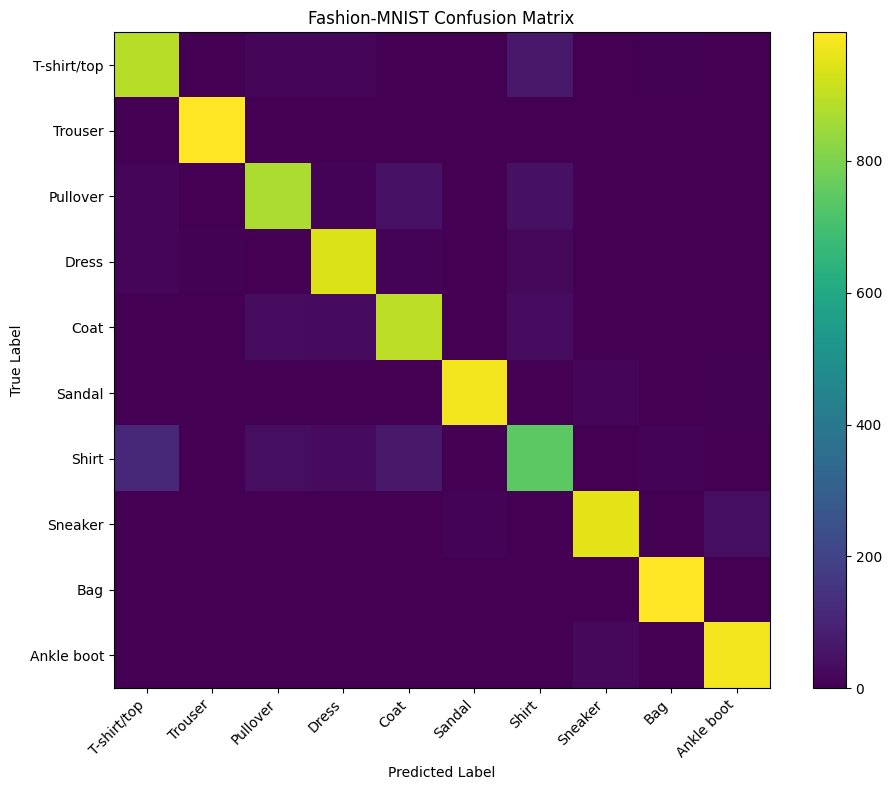

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fashion-MNIST Confusion Matrix")

plt.colorbar()

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    class_names
)

plt.tight_layout()

plt.show()

In [ ]:
import os

print(
    f"Model exists: "
    f"{os.path.exists('cnn_best_model.pth')}"
)

print(
    f"Model size: "
    f"{os.path.getsize('cnn_best_model.pth') / (1024**2):.2f} MB"
)

Model exists: True
Model size: 1.65 MB


In [ ]:
from google.colab import files

files.download("cnn_best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>